# Tracking × calls

## What the tracking repo gives us

One CSV per video, at `Video/<date>/<exp>/video_<camera>_<idx>.csv`. **One row = one animal seen in
one frame.**

| column | meaning |
|---|---|
| `frame_id` | frame number; **seconds into the video = `frame_id / 30`** |
| `det_id` | index within that frame only — **resets every frame, it is NOT an identity** |
| `conf` | detection confidence, 0–1 (below 0.25 already dropped) |
| `center_x`, `center_y` | position in **cm**, arena is 121 × 91 |
| `bbox_*` | box in **pixels** of the 1600×1200 frame — different coordinate system, don't mix |
| `stationary` | **0/1 — the detector locked onto a fixed object, not an animal** |

Three things that bite if forgotten:

- **No identity across frames.** We can count animals and locate them; we cannot follow one.
- **Empty frames are omitted**, so a missing frame means "nothing detected", and row count ≠ frame count.
- **Positions are clamped** into the arena, so detections outside it pile up exactly on the bounds.

## How we read it here

`scripts/pipeline/pool_detections.py --date-folder <DATE>` turns those CSVs into two files per date
folder, and everything below reads those, never the raw CSVs:

- **`detections_<date>.parquet`** — every detection, plus `exp`, `location` (`arena_1`/`arena_2`,
  the same vocabulary the calls use — camera names stay in the filenames), and **`start_time_real`,
  the same clock as `all_calls`**, so a call and a detection at the same moment join directly.
- **`files_vetted_<date>.csv`** — one row per video that was tracked. This is how "nobody was
  visible" is told apart from "that video was never looked at"; without it, both are just absent
  rows. It also carries `stationary_source`.

**Neither rule is left to memory.**

1. **`pool_detections.py` removes the stationary rows when it pools** — the file you read is already
   clean, whatever you open it with. The per-experiment files keep them as the audit trail, and
   `files_vetted.n_stationary` counts what went.
2. **`scripts/utils/tracking_io.py` handles the filmed-minutes rule** — `animals_per_minute()` counts
   only minutes that were tracked, so a quiet minute is a zero and an untracked one is absent.

For reference, the rules themselves:

1. **Stationary detections must go** — 13% of arena_2 in 2026_02 (a piece of plastic a gerbil
   dragged in). Occupancy is meaningless without removing them.
2. **Count minutes from `files_vetted`, not from the detections** — otherwise an untracked camera
   silently becomes an empty arena.

`stationary_source` says who computed the flag: `detector` (the tracking repo, the good one) or
`fallback` (our coarser local rule, still used for 5 experiments they have not reached — those are
under-flagged, so treat them as provisional).

Caveat unrelated to the video: calls are assigned to whichever channel DAS fired on, and arena_1
calls leak into arena_2. Read arena_1 with confidence, arena_2 with suspicion.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.utils.tracking_io import (load_detections, load_files_vetted,
                                       animals_per_minute, FPS, FRAMES_PER_MINUTE)
from scripts.pipeline.pool_calls import add_exp_times

DATE = "2026_02"

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2.0})
COLOURS = {"arena_1": "#4c6ef5", "arena_2": "#f08c00"}

In [2]:
# The pooled file is already free of the detector's fixed-object detections —
# pool_detections drops them. load_detections just reads it.
detections = load_detections(DATE)
videos = load_files_vetted(DATE)

print(f"{len(detections):,} detections, {detections.exp.nunique()} experiments")

26,245,714 detections, 28 experiments


## 1. The data, and how to work with it

One row per animal seen in one frame.

In [3]:
detections.head(3)

,exp,location,file_num,frame_id,det_id,conf,center_x,center_y,bbox_x1,bbox_y1,bbox_x2,bbox_y2,start_time_real,stationary
0,492,arena_1,2,5725,0,0.7800,100.33,70.88,1197,844,1273,931,2026-02-18 15:55:51.833333333,False
1,492,arena_1,2,5726,0,0.6975,100.42,70.79,1197,846,1274,930,2026-02-18 15:55:51.866666667,False
2,492,arena_1,2,5727,0,0.5128,100.23,70.60,1197,843,1274,927,2026-02-18 15:55:51.900000000,False


In [4]:
# --- the three manipulations used throughout ---

# a) FILTER rows with a condition in square brackets
arena_1_only = detections[detections.location == "arena_1"]
print("filter :", len(arena_1_only), "rows in arena_1")

# b) ADD a column by computing from existing ones
one_video = detections[(detections.exp == 492) & (detections.file_num == 2)].copy()
one_video["seconds_into_video"] = one_video["frame_id"] / FPS
print("new col:", one_video[["frame_id", "seconds_into_video"]].head(2).to_dict("records"))

# c) GROUP rows and count / average within each group
per_location = detections.groupby("location").size()
print("group  :", per_location.to_dict())

filter : 15329586 rows in arena_1
new col: [{'frame_id': 5725, 'seconds_into_video': 190.83333333333334}, {'frame_id': 5726, 'seconds_into_video': 190.86666666666667}]


group  : {'arena_1': 15329586, 'arena_2': 10916128}


**`.copy()` matters in (b).** `one_video` is a slice of `detections`; without `.copy()` pandas warns
that you are assigning into a view of the original. Copy first, then add columns.

**Careful with column names.** `df.sem` and `df.mean` give you pandas *methods*, not your columns of
those names — that is why the columns below are `error` and `mean_per_animal`. When in doubt use
`df["name"]`, which always means the column.

## 2. Minutes: how many animals, how many calls

One row per experiment, location and minute.

In [5]:
# animals_per_minute lives in scripts/utils/tracking_io.py — it counts detections
# per minute and, crucially, only over minutes that were actually filmed.

def calls_per_minute(exp):
    """Number of calls assigned to each location, per minute of one experiment."""
    c = add_exp_times(exp)
    c["minute"] = c["start_time_real"].dt.floor("1min")
    counted = c.groupby(["assigned_location", "minute"]).size().reset_index(name="calls")
    return counted.rename(columns={"assigned_location": "location"})

In [6]:
rows = []
for exp in sorted(detections.exp.unique()):
    table = animals_per_minute(DATE, exp)
    table = table.merge(calls_per_minute(exp), on=["location", "minute"], how="left")
    table["calls"] = table["calls"].fillna(0)
    rows.append(table)

minutes = pd.concat(rows, ignore_index=True)
minutes = minutes[minutes.location.isin(["arena_1", "arena_2"])]
print(f"{len(minutes):,} filmed minutes")
minutes.head(3)

23,520 filmed minutes


,location,minute,animals,calls,exp
0,arena_1,2026-02-18 15:40:00,0.0,0.0,492
1,arena_1,2026-02-18 15:41:00,0.0,0.0,492
2,arena_1,2026-02-18 15:42:00,0.0,0.0,492


## 3. The two arenas side by side

Same minutes, one column per arena — easier to compare than the stacked form above.

In [7]:
arena_1 = minutes[minutes.location == "arena_1"]
arena_2 = minutes[minutes.location == "arena_2"]

side_by_side = arena_1.merge(arena_2, on=["exp", "minute"], suffixes=("_1", "_2"))
side_by_side = side_by_side[["exp", "minute", "animals_1", "calls_1", "animals_2", "calls_2"]]

print(f"{len(side_by_side):,} minutes where BOTH arenas were filmed")
side_by_side.head(5)

10,140 minutes where BOTH arenas were filmed


,exp,minute,animals_1,calls_1,animals_2,calls_2
0,492,2026-02-18 15:40:00,0.0,0.0,0.0,0.0
1,492,2026-02-18 15:41:00,0.0,0.0,0.0,0.0
2,492,2026-02-18 15:42:00,0.0,0.0,0.0,0.0
3,492,2026-02-18 15:43:00,0.0,0.0,0.0,0.0
4,492,2026-02-18 15:44:00,0.0,0.0,0.0,0.0


In [8]:
print(side_by_side[["animals_1", "calls_1", "animals_2", "calls_2"]].describe().round(2))

       animals_1   calls_1  animals_2   calls_2
count   10140.00  10140.00   10140.00  10140.00
mean        0.61      7.43       0.45      5.63
std         0.89     15.63       0.76     14.66
min         0.00      0.00       0.00      0.00
25%         0.00      0.00       0.00      0.00
50%         0.00      0.00       0.00      0.00
75%         1.01      7.00       0.83      2.00
max         6.33    160.00       5.40    204.00


## 4. Call rate vs number of animals

In [9]:
minutes = minutes.copy()
minutes["n_animals"] = minutes["animals"].round()

summary = minutes.groupby(["location", "n_animals"]).agg(
    mean_calls=("calls", "mean"),
    error=("calls", "sem"),               # standard error, for the error bars
    n_minutes=("calls", "size"),
).reset_index()

summary = summary[summary.n_minutes >= 20]
summary

,location,n_animals,mean_calls,error,n_minutes
0,arena_1,0.0,0.572896,0.032463,7401
1,arena_1,1.0,9.914579,0.248415,2634
2,arena_1,2.0,24.760899,0.498790,1468
3,arena_1,3.0,37.626437,1.093977,522
4,arena_1,4.0,46.684783,3.097435,92
7,arena_2,0.0,0.492486,0.040533,7785
8,arena_2,1.0,8.965766,0.297986,2220
9,arena_2,2.0,27.372070,0.722371,1024
10,arena_2,3.0,37.702970,1.479123,303
11,arena_2,4.0,56.187500,5.391060,48


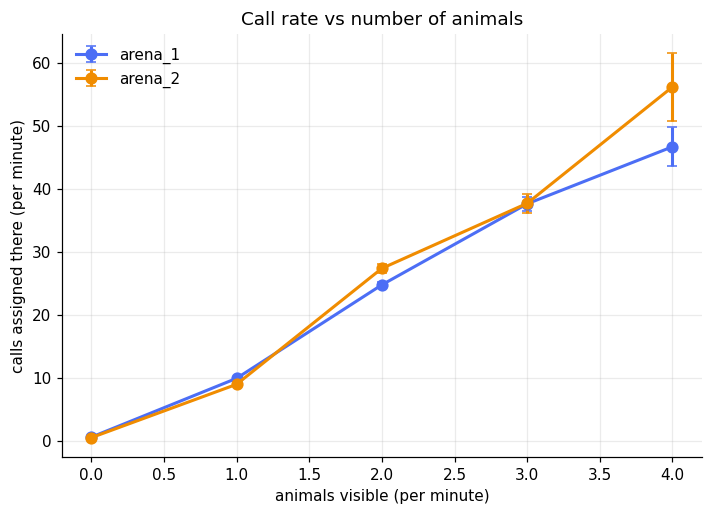

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for location in ["arena_1", "arena_2"]:
    r = summary[summary.location == location]
    ax.errorbar(r.n_animals, r.mean_calls, yerr=r["error"], fmt="o-",
                color=COLOURS[location], markersize=7, capsize=3, label=location)
ax.set_xlabel("animals visible (per minute)")
ax.set_ylabel("calls assigned there (per minute)")
ax.set_title("Call rate vs number of animals")
ax.legend(frameon=False)
plt.show()

## 5. Calls per animal — and is the rise linear?

**If call rate rose linearly with headcount, calls per animal would be a flat line.** That is the whole
test: divide by `n_animals` and look for flatness. Rising = each animal calls more when it has
company (superlinear); falling = each calls less (sublinear).

The error bars decide whether a bend is real or just few minutes.

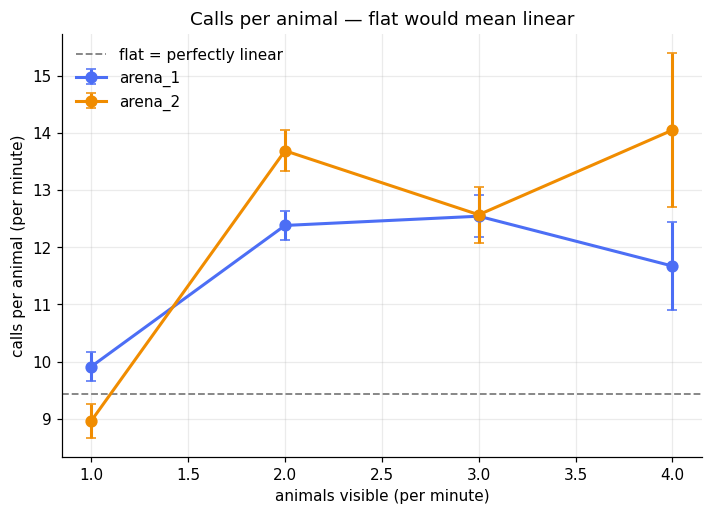

  location  n_animals  mean_per_animal  error  n_minutes
0  arena_1        1.0             9.91   0.25       2634
1  arena_1        2.0            12.38   0.25       1468
2  arena_1        3.0            12.54   0.36        522
3  arena_1        4.0            11.67   0.77         92
6  arena_2        1.0             8.97   0.30       2220
7  arena_2        2.0            13.69   0.36       1024
8  arena_2        3.0            12.57   0.49        303
9  arena_2        4.0            14.05   1.35         48


In [11]:
per_animal = minutes[minutes.n_animals >= 1].copy()
per_animal["calls_per_animal"] = per_animal["calls"] / per_animal["n_animals"]

summary_per_animal = per_animal.groupby(["location", "n_animals"]).agg(
    mean_per_animal=("calls_per_animal", "mean"),
    error=("calls_per_animal", "sem"),
    n_minutes=("calls_per_animal", "size"),
).reset_index()
summary_per_animal = summary_per_animal[summary_per_animal.n_minutes >= 20]

fig, ax = plt.subplots(figsize=(7.5, 5))
for location in ["arena_1", "arena_2"]:
    r = summary_per_animal[summary_per_animal.location == location]
    ax.errorbar(r.n_animals, r["mean_per_animal"], yerr=r["error"], fmt="o-",
                color=COLOURS[location], markersize=7, capsize=3, label=location)
ax.axhline(summary_per_animal[summary_per_animal.n_animals == 1]["mean_per_animal"].mean(),
           color="0.5", ls="--", lw=1.2, label="flat = perfectly linear")
ax.set_xlabel("animals visible (per minute)")
ax.set_ylabel("calls per animal (per minute)")
ax.set_title("Calls per animal — flat would mean linear")
ax.legend(frameon=False)
plt.show()

print(summary_per_animal.round(2))

### Putting a number on it

Fit `calls = a · n^b`. Taking logs makes it a straight line, so `b` comes from a linear fit:

- **b = 1** → exactly linear (double the animals, double the calls)
- **b > 1** → superlinear, animals call more in company
- **b < 1** → sublinear

In [12]:
for location in ["arena_1", "arena_2"]:
    d = minutes[(minutes.location == location) & (minutes.n_animals >= 1) & (minutes.calls > 0)]

    log_animals = np.log(d["n_animals"])
    log_calls = np.log(d["calls"])
    b, log_a = np.polyfit(log_animals, log_calls, 1)

    # rough uncertainty on b: scatter of the residuals / spread of x
    residuals = log_calls - (b * log_animals + log_a)
    se = residuals.std() / (log_animals.std() * np.sqrt(len(d)))

    print(f"{location}: b = {b:.2f} ± {1.96*se:.2f}   (n = {len(d):,} minutes)")

arena_1: b = 1.26 ± 0.07   (n = 4,075 minutes)
arena_2: b = 1.36 ± 0.09   (n = 2,826 minutes)


## 6. How far apart are the animals?

The goal: **do calls happen when animals are close together, or far apart?**

Two decisions worth stating, because they shape the answer.

**How many neighbours.** Distance to the *k* nearest neighbours needs k+1 animals visible at once.
For k=3 that is 4+ animals, which happens in only **4.5%** of arena_1 frames — and those are the
busiest moments, which we already know are the most vocal. k=1 needs 2 animals: **46.6%** of frames.
`K_NEIGHBOURS` below is a parameter; try 3 and watch the usable frames collapse.

**Crowding is a confound.** More animals in a fixed arena means smaller distances, automatically. And
call rate already rises with headcount. So we always compare **within the same number of animals**,
never across.

In [13]:
# One experiment at a time, keeping only the small per-frame result.
# One frame per second is plenty: animals barely move in 1/30 s, and it is 30x cheaper.
from scripts.utils.tracking_io import experiments_in

spacing_rows = []
for exp in experiments_in(DATE):
    positions = load_detections(DATE, exp=exp, location=ARENA, quiet=True,
                                columns=["file_num", "frame_id", "center_x", "center_y",
                                         "start_time_real"])
    positions = positions[positions.frame_id % FPS == 0]

    for (file_num, frame_id), frame in positions.groupby(["file_num", "frame_id"]):
        distance = mean_distance_to_neighbours(frame.center_x.values, frame.center_y.values,
                                               K_NEIGHBOURS)
        if np.isnan(distance):
            continue
        spacing_rows.append({"exp": exp, "file_num": file_num, "frame_id": frame_id,
                             "time": frame.start_time_real.iloc[0],
                             "n_animals": len(frame), "distance": distance})

spacing = pd.DataFrame(spacing_rows)
print(f"{len(spacing):,} frames usable with K_NEIGHBOURS={K_NEIGHBOURS}")
print(spacing.groupby("n_animals")["distance"].agg(["size", "mean"]).round(1).head())

511,066 detections at 1 frame per second


In [14]:
def mean_distance_to_neighbours(x_values, y_values, k):
    """Mean distance from each animal to its k nearest neighbours, in cm.

    Returns NaN when there are not enough animals in the frame (needs k+1).
    """
    if len(x_values) < k + 1:
        return np.nan

    points = np.column_stack([x_values, y_values])
    distances = squareform(pdist(points))      # square matrix, animal x animal
    np.fill_diagonal(distances, np.inf)        # ignore each animal's distance to itself

    distances.sort(axis=1)                     # each row: neighbours nearest first
    nearest_k = distances[:, :k]
    return nearest_k.mean()

In [15]:
# (replaced by the per-experiment loop above)


140,743 frames usable with K_NEIGHBOURS=1
            size  mean
n_animals             
2          90484  55.3
3          37039  39.5
4          10436  31.1
5           2235  25.9
6            450  21.9


### Was there a call at that second?

Mark each frame with whether a call was assigned to this arena within that second, then compare the
spacing of calling seconds against silent ones — **separately for each animal count**.

In [16]:
call_seconds = set()
for exp in sorted(spacing.exp.unique()):
    c = add_exp_times(exp)
    c = c[c.assigned_location == ARENA]
    for t in c.start_time_real.dt.floor("s"):
        call_seconds.add((exp, t))

spacing["second"] = spacing["time"].dt.floor("s")
spacing["has_call"] = [(e, s) in call_seconds for e, s in zip(spacing.exp, spacing.second)]
print(f"{spacing.has_call.sum():,} of {len(spacing):,} frames had a call in that second")

39,110 of 140,743 frames had a call in that second


In [17]:
comparison = spacing.groupby(["n_animals", "has_call"]).agg(
    mean_distance=("distance", "mean"),
    error=("distance", "sem"),
    n_frames=("distance", "size"),
).reset_index()

comparison = comparison[comparison.n_frames >= 50]
comparison.round(2)

,n_animals,has_call,mean_distance,error,n_frames
0,2,False,57.66,0.14,69031
1,2,True,47.76,0.23,21453
2,3,False,40.79,0.13,25017
3,3,True,36.81,0.17,12022
4,4,False,32.47,0.18,6207
5,4,True,29.06,0.20,4229
6,5,False,27.11,0.31,1135
7,5,True,24.60,0.32,1100
8,6,False,23.21,0.59,194
9,6,True,20.95,0.46,256


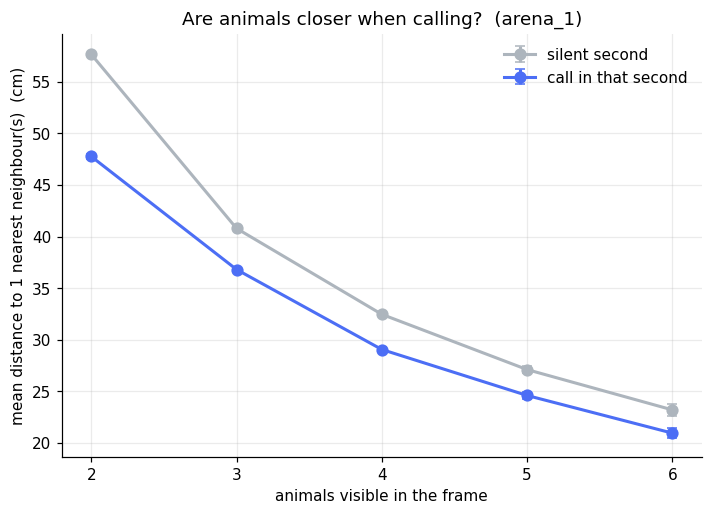

In [18]:
counts = sorted(comparison.n_animals.unique())
fig, ax = plt.subplots(figsize=(7.5, 5))

for has_call, colour, label in [(False, "#adb5bd", "silent second"), (True, "#4c6ef5", "call in that second")]:
    rows_ = comparison[comparison.has_call == has_call]
    ax.errorbar(rows_.n_animals, rows_.mean_distance, yerr=rows_["error"],
                fmt="o-", color=colour, markersize=7, capsize=3, label=label)

ax.set_xlabel("animals visible in the frame")
ax.set_ylabel(f"mean distance to {K_NEIGHBOURS} nearest neighbour(s)  (cm)")
ax.set_title(f"Are animals closer when calling?  ({ARENA})")
ax.set_xticks(counts)
ax.legend(frameon=False)
plt.show()

Compare the two lines **at the same x** — that is the whole point of splitting by animal count. A
gap between them means spacing differs between calling and silent moments for the *same* number of
animals, so it is not just crowding.

Caveats: a call is attributed to the arena by audio, which is unreliable for arena_2 (hence
`ARENA = "arena_1"`); animals in the burrow are invisible; and a second is coarse — a call lasts tens
of milliseconds, so this asks "were they close around the time of the call", not "at the instant".

## Questions next

1. **Time of day is a confound.** Occupancy and calling both vary over the day, so this relationship
   could be hours, not company. Compare minutes *within the same hour* to separate them.
2. Does the slope hold in most of the 28 experiments, or is it carried by a few?
3. Split by **call type** — more robust than location in the current calls table.